### FASE 3. Análisis Exploratorio de Datos (EDA)

**Proyecto:** Análisis Exploratorio de Datos — Ingresos totales por ventas a clientes de un comercio.

**Objetivo de esta fase:**
Comprender el comportamiento de los datos mediante estadísticas descriptivas y visualizaciones, identificando patrones, relaciones entre variables y, especialmente, qué factores se asocian a que un cliente (variable `ìd_cliente`) que realiza una compra (variable `order_id`).

**Punto de partida:** `02_datos_limpios.csv` (52.000 filas × 39 columnas), resultado de la Fase 2.

**Flujo que seguiremos:**
1. Recordatorio Pre-EDA.
2. Identificar variables categóricas y numéricas.
3. Análisis univariante (categóricas y numéricas).
4. Análisis bivariante — relación con la variable objetivo `y`.
5. Relación entre variables numéricas y correlaciones globales.
6. Evolución temporal.
7. Preguntas de negocio.
8. Conclusiones de la fase.


In [8]:
# Libreria de Tratamiento de Datos
import pandas as pd
import numpy as np
from IPython.display import display

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Exploracion de Archivos de soporte
import sys
sys.path.append('../') # para que busque en carpeta src 
from src import sp_eda as se

# Para que se muestren todas las columnas al imspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns',None)

In [9]:
df = pd.read_csv(
    "../data/processed/02_datos_limpios.csv",
    parse_dates=['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro']
)

#### EXPLORACION INICAL

In [10]:
se.exploracion(df)

PRIMERAS COLUMNAS


,45605,22041,3561
order_id,45606,22042,3562
id_cliente,99d813b0-276c-438e-a7b6-0c0b35c0e7f8,f9448f16-d80e-4961-b116-2841d761f32e,b61d5bde-a588-40f7-9235-9437060f7f56
product_id,P0018,P0011,P0058
fecha_pedido,2025-11-22 00:00:00,2023-07-09 00:00:00,2022-05-01 00:00:00
cantidad,2,1,1
precio_unitario,41.1,67.67,37.39
descuento,0.1,0.05,0.05
importe_total,73.99,64.29,35.52
metodo_pago,paypal,tarjeta de debito,paypal
envio_gratis,no,no,no


::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
INFORMACIÓN BÁSICA
<class 'pandas.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  52000 non-null  int64         
 1   id_cliente                52000 non-null  str           
 2   product_id                52000 non-null  str           
 3   fecha_pedido              52000 non-null  datetime64[us]
 4   cantidad                  52000 non-null  int64         
 5   precio_unitario           52000 non-null  float64       
 6   descuento                 52000 non-null  float64       
 7   importe_total             52000 non-null  float64       
 8   metodo_pago               52000 non-null  str           
 9   envio_gratis              52000 non-null  str           
 10  calificacion              52000 n

None

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
ESTADISTICOS


...

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
TAMAÑO DATAFRAME
(52000, 39)
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
NULOS


fecha_registro    253
dtype: int64

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
PORCENTAJE DE NULOS


fecha_registro    0.49
dtype: float64

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
DUPLICADOS
0


##### COMPROBACION VALORES CLAVES

In [11]:
valores_claves = ['order_id', 'id_cliente']
se.comprobar_claves(df, valores_claves)

Valores claves:
order_id: 0 duplicados
order_id: 52000 unicos
Valores claves:
id_cliente: 44013 duplicados
id_cliente: 7987 unicos


`order_id` es único (1 fila = 1 pedido). `id_cliente` se repite porque un 
cliente hace varios pedidos — es correcto, no un error de duplicados.

##### CREAR TABLA CLIENTES

Tabla clientes (agregada a nivel cliente):

In [12]:
clientes = df.groupby('id_cliente').agg(
    n_pedidos=('order_id', 'count'),
    gasto_total=('importe_total_wz', 'sum'),
    edad=('edad', 'first'),
    ciudad=('ciudad', 'first'),
    segmento_cliente=('segmento_cliente', 'first'),
    ingresos_anuales=('ingresos_anuales', 'first')
    ).reset_index()

clientes["ticket_medio"] = (
    clientes["gasto_total"] / clientes["n_pedidos"]
)

clientes.T

0                                     1                                     2                                     3                                     4                                     5                                     6                                     7                                     8                                     9                                     10                                    11                                    12                                    13                                    14                                    15                                    16                                    17                                    18                                    19                                    20                                    21                                    22                                    23                                    24                                    25                                    26                                    27                                    28                                    29                                    30                                    31                                    32                                    33                                    34                                    35                                    36                                    37                                    38                                    39                                    40                                    41                                    42                                    43                                    44                                    45                                    46                                    47                                    48                                    49                                    50                                    51                                    52                                    53                                    54                                    55                                    56                                    57                                    58                                    59                                    60                                    61                                    62                                    63                                    64                                    65                                    66                                    67                                    68                                    69                                    70                                    71                                    72                                    73                                    74                                    75                                    76                                    77                                    78                                    79                                    80                                    81                                    82                                    83                                    84                                    85                                    86                                    87                                    88                                    89                                    90                                    91                                    92                                    93                                    94                                    95                                    96                                    97                                    98                                    99                                    100                                   101                                   102                                   103                                   104                                   105       

##### EDA PRELIMINAR

EDA AUTOMÁTICO (vista rápida de todas las variables)

In [13]:
cols_excluir = ['order_id', 'id_cliente', 'product_id', 'nombre_producto',
                 'latitude', 'longitude', 'precio_unitario','importe_total']

VARIABLES NUMERICAS:

 Index(['cantidad', 'descuento', 'calificacion', 'año_ventas', 'costo_unitario', 'precio_lista', 'peso_kg', 'stock_disponible', 'rating_promedio_producto', 'edad', 'ingresos_anuales', 'visitas_web_mes', 'precio_unitario_wz', 'importe_total_wz'], dtype='str')

VARIABLES CATEGORICAS:

 Index(['metodo_pago', 'envio_gratis', 'devuelto', 'canal', 'categoria_producto', 'marca', 'proveedor', 'estado_civil', 'nivel_educativo', 'tiene_hijos', 'adolescentes_en_casa', 'ciudad', 'region', 'segmento_cliente'], dtype='str')

VARIABLES DATETIME(FECHA):

 Index(['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro'], dtype='str')

========== ESTADÍSTICAS BÁSICAS ==========

VARIABLES NUMERICAS:


                            count      mean       std       min       25%       50%       75%        max
cantidad                  52000.0      2.05      1.20      1.00      1.00      2.00      3.00       5.00
descuento                 52000.0      0.07      0.08      0.00      0.00      0.05      0.10       0.30
calificacion              52000.0      4.04      0.97      1.00      4.00      4.00      5.00       5.00
año_ventas                52000.0   2023.50      1.12   2022.00   2022.75   2023.50   2024.25    2025.00
costo_unitario            52000.0     32.40     20.45      5.24     17.00     26.73     42.03      96.15
precio_lista              52000.0     56.91     37.45      9.70     31.07     45.86     77.93     211.36
peso_kg                   52000.0      6.22      3.51      0.30      2.95      6.89      9.28      11.98
stock_disponible          52000.0    250.00    134.01      5.00    148.00    263.00    368.00     488.00
rating_promedio_producto  52000.0      3.88      0.67  

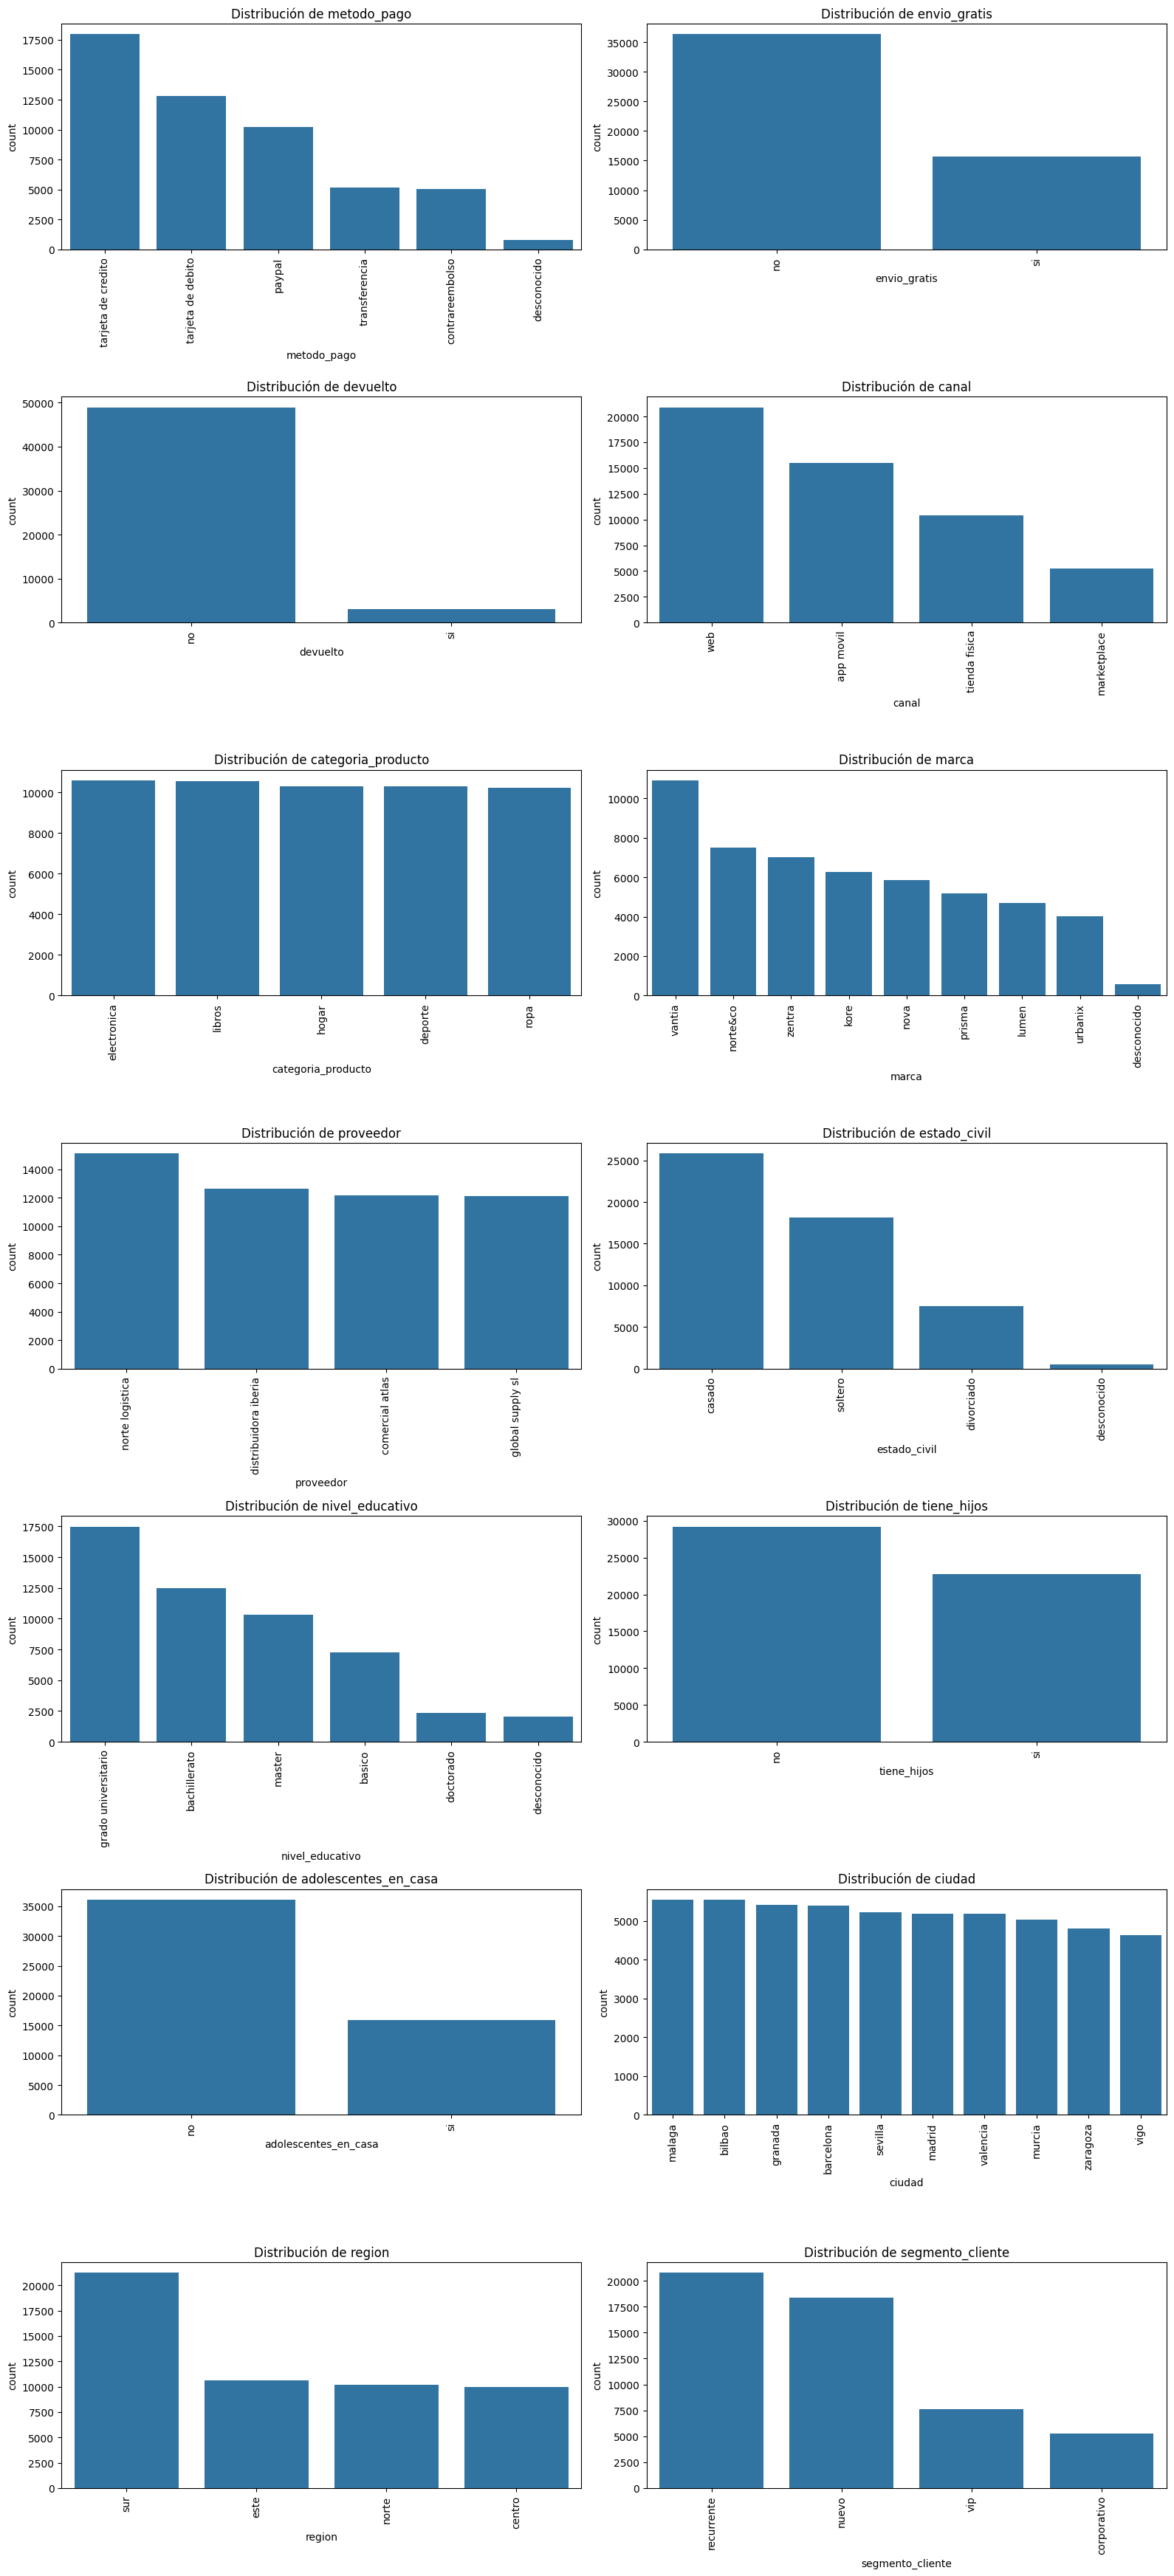


============== HISTOGRAMAS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS):


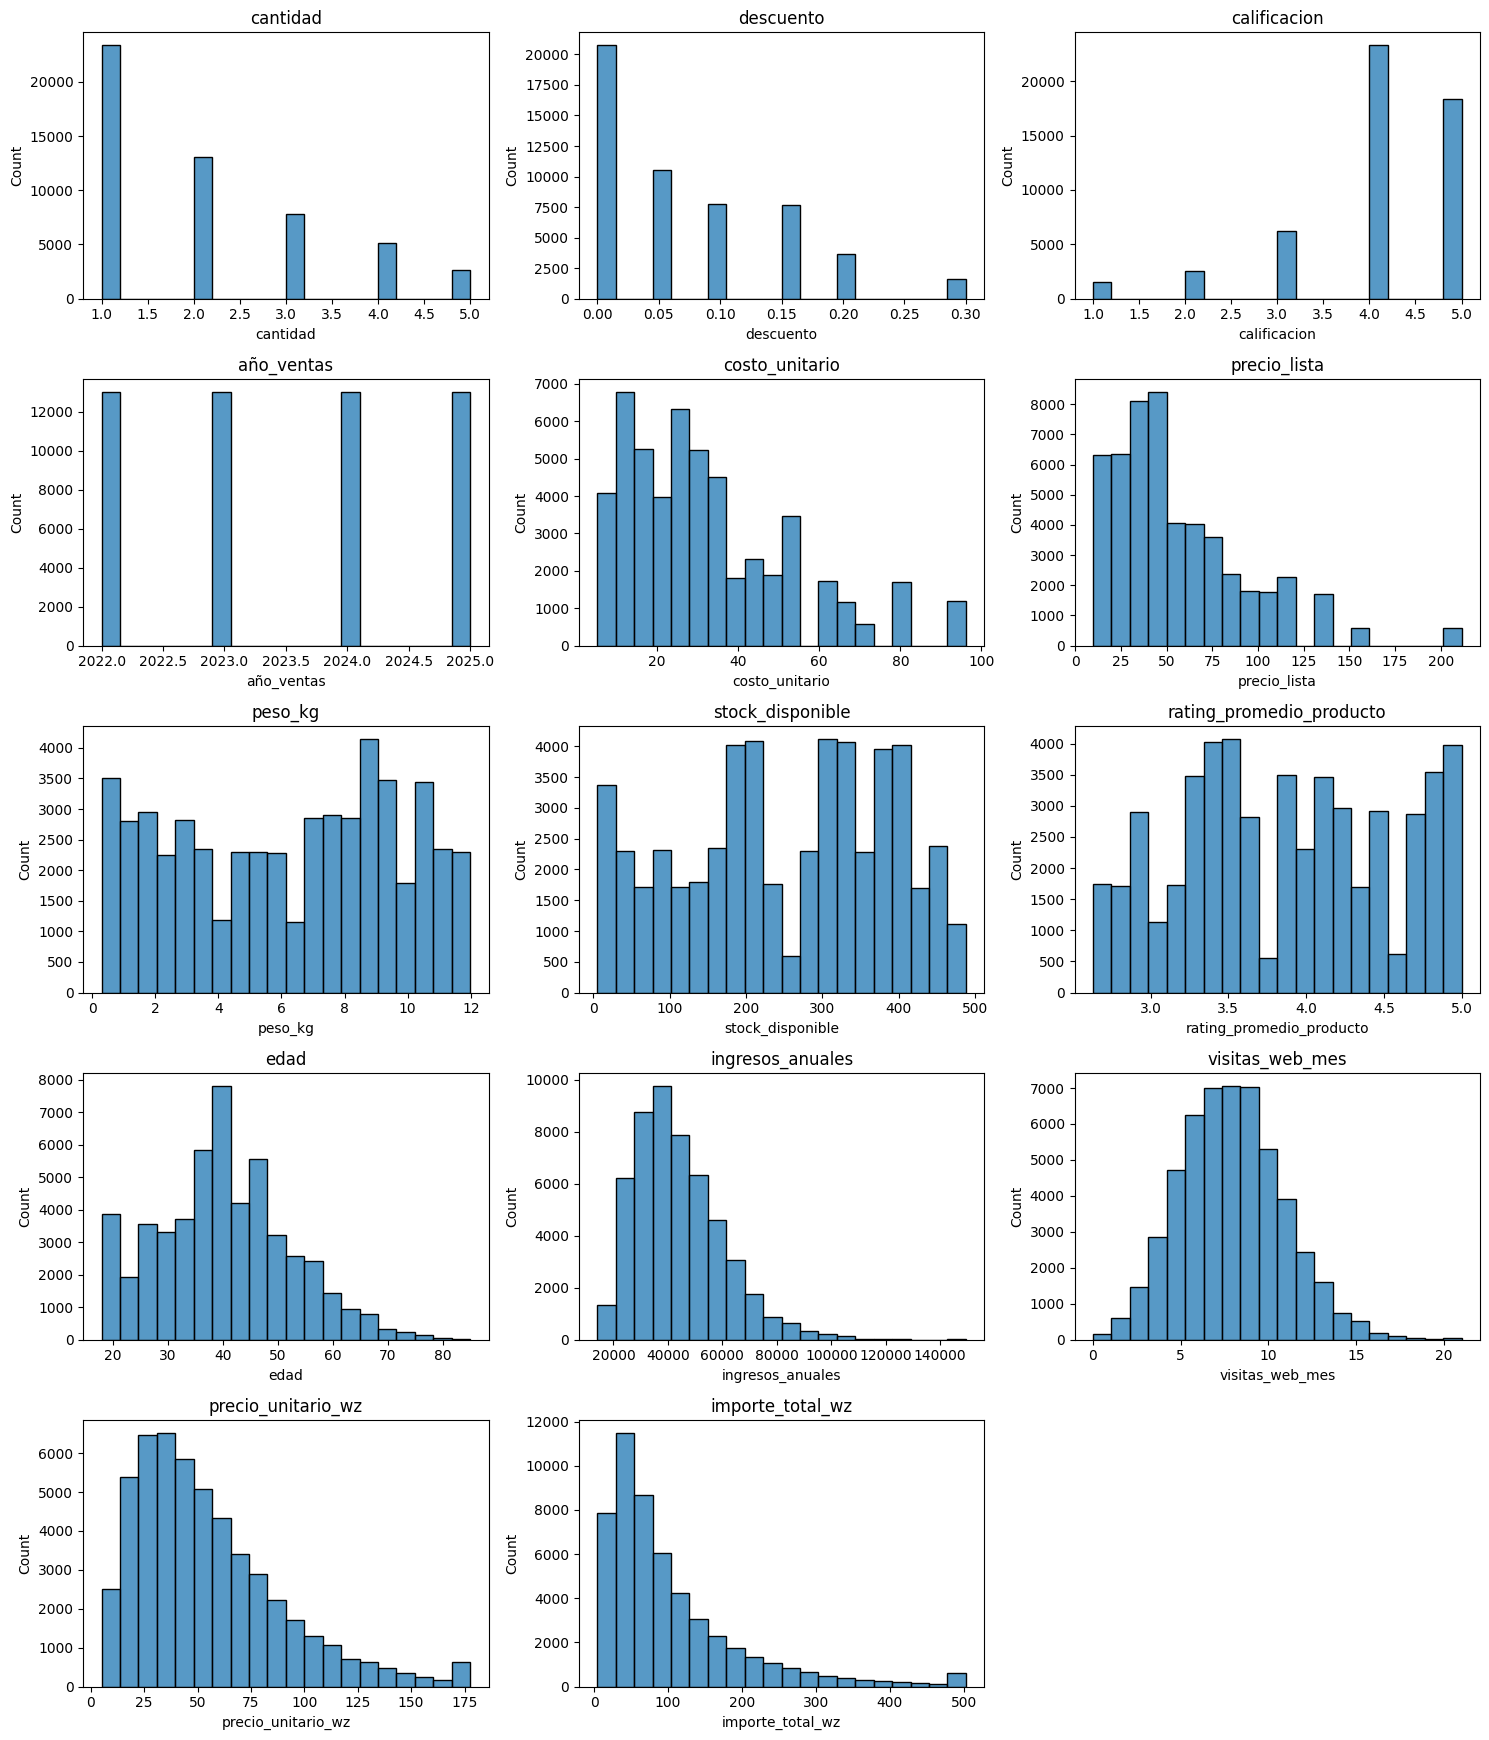


============== BOXPLOTS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS - OUTLIERS)


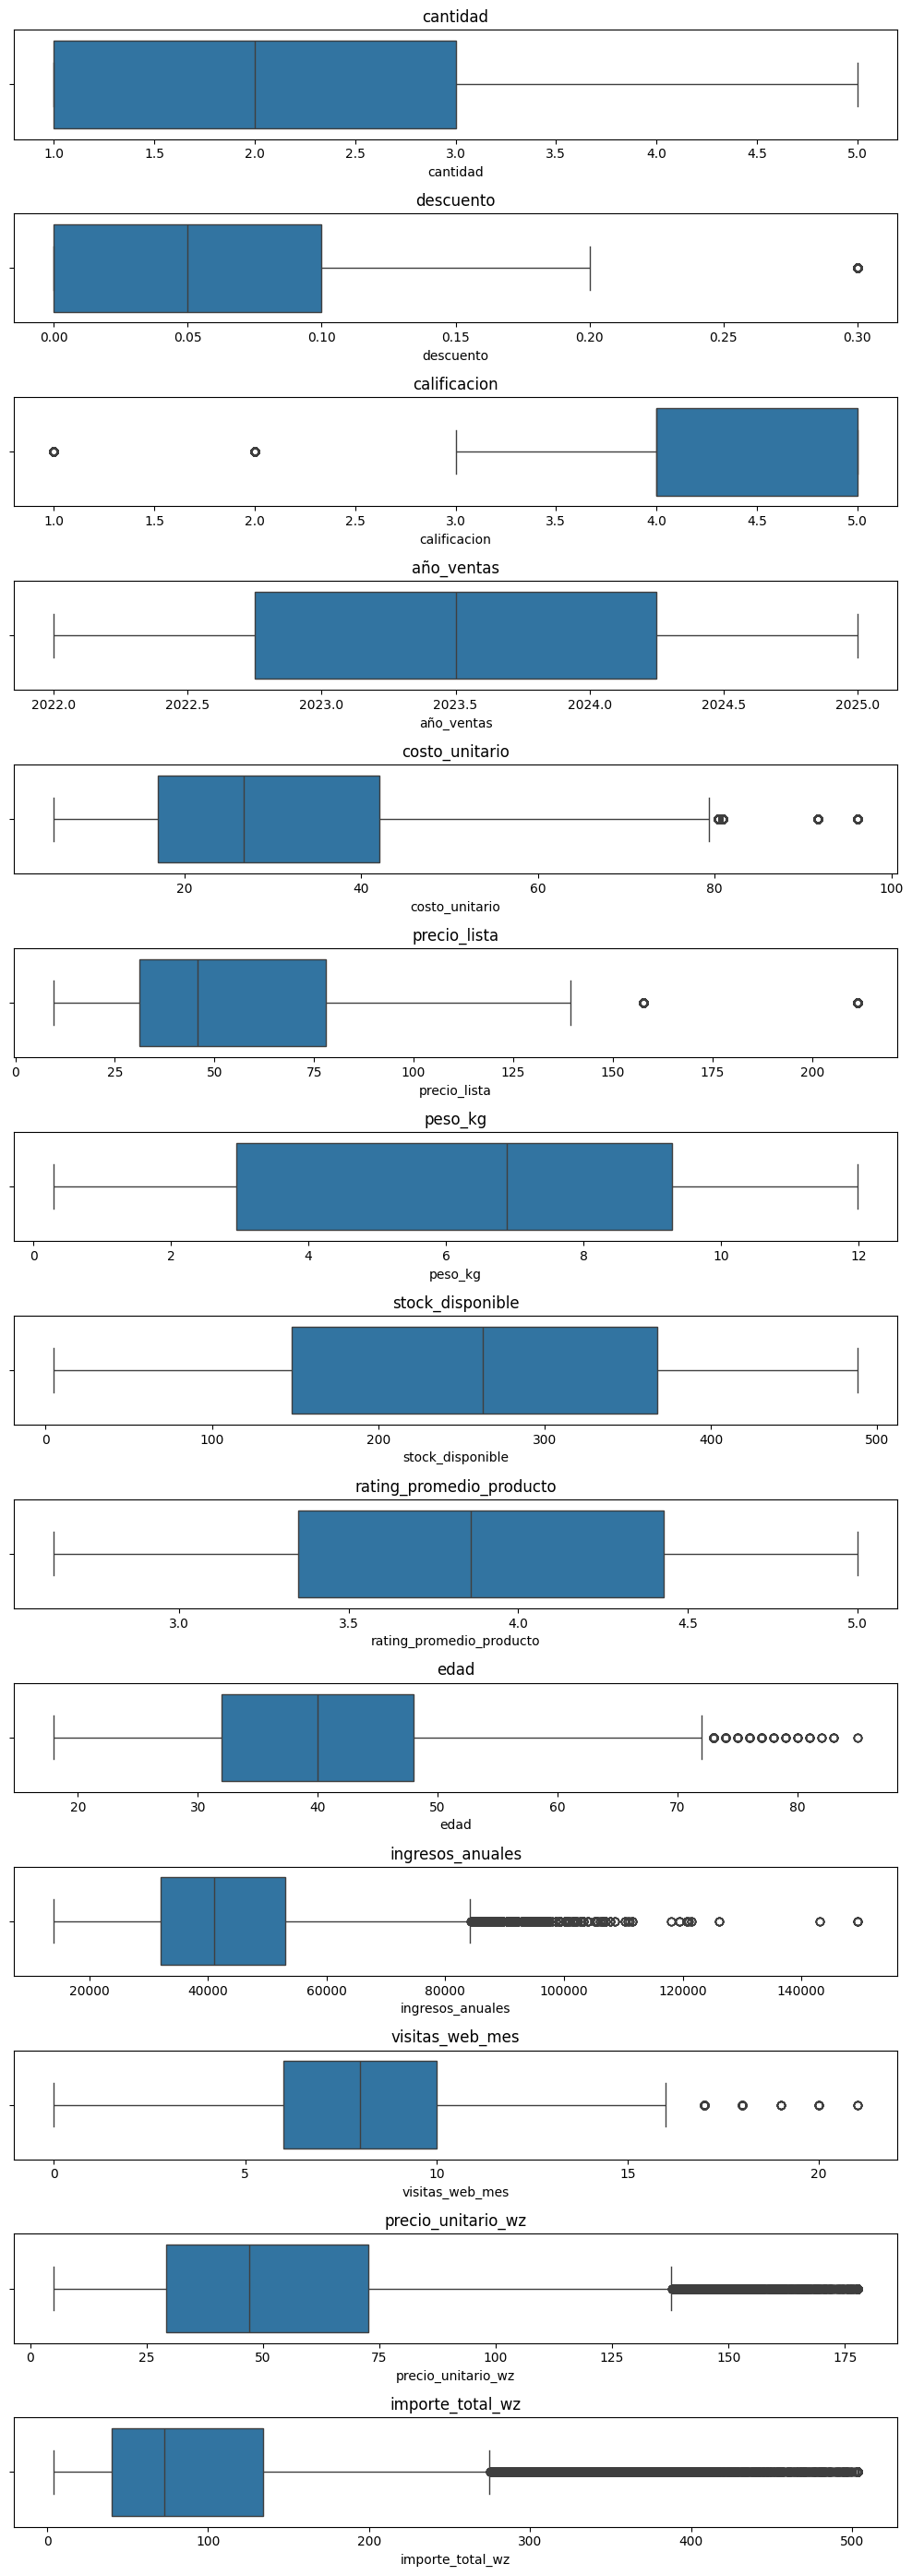

In [14]:
se.eda(df,cols_excluir=cols_excluir)

#### PROFUNDIZANDO EN VARIABLES CLAVE

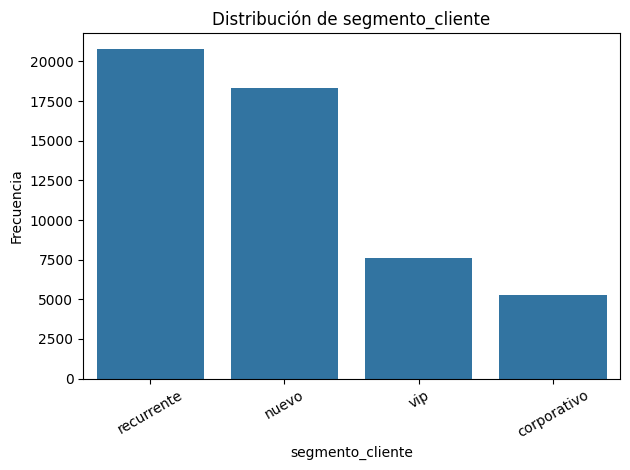

segmento_cliente
recurrente     20768
nuevo          18344
vip             7596
corporativo     5292
Name: count, dtype: int64


In [20]:
se.countplot(df, 'segmento_cliente')

**Observación:** revisa si hay algún segmento minoritario que luego pueda 
dar problemas de tamaño muestral al cruzarlo con otras variables.

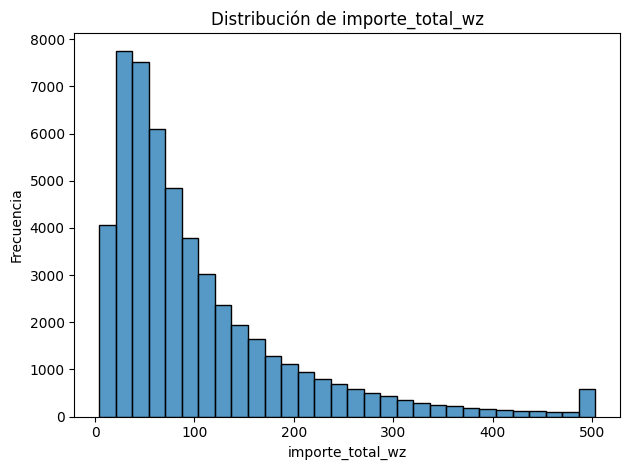

count    52000.00
mean       104.17
std         95.15
min          4.22
25%         40.02
50%         72.52
75%        133.94
max        503.06
Name: importe_total_wz, dtype: float64


In [21]:
se.histplot(df, 'importe_total_wz')

**Observación:** anota si la distribución está sesgada a la derecha (típico 
en importes de venta) — eso condiciona si luego usas media o mediana en 
los bivariantes.

Histograma importe_total_wz

Dos cosas a anotar:

- Distribución sesgada a la derecha (asimetría positiva) — la mayoría de pedidos están entre 20€ y 150€, con una cola larga hacia importes altos. Normal en datos de venta. Para el bivariante, esto significa que si comparas medias entre grupos, unos pocos pedidos grandes pueden distorsionar el resultado — vale la pena mirar también la mediana, no solo la media.
- Ese pico anómalo justo en 500€ no es un patrón real de compra — es un artefacto del winsorizing. La columna importe_total_wz (el sufijo _wz confirma que es la versión winsorizada) tiene un tope superior fijo, y todos los valores que originalmente superaban ese límite se han "apilado" ahí. Es importante que lo tengas claro para no interpretarlo como "mucha gente gasta exactamente ~500€".

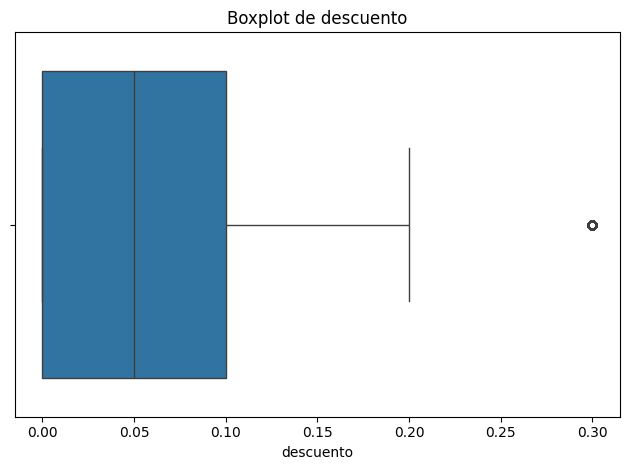

count    52000.00
mean         0.07
std          0.08
min          0.00
25%          0.00
50%          0.05
75%          0.10
max          0.30
Name: descuento, dtype: float64


In [22]:
se.boxplot(df, 'descuento')

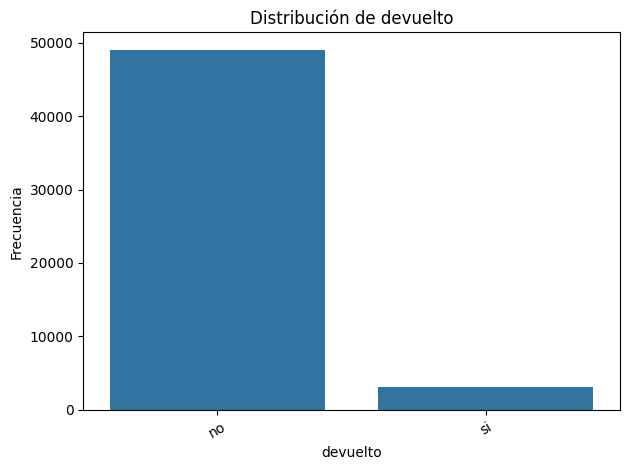

devuelto
no    48941
si     3059
Name: count, dtype: int64


In [23]:
se.countplot(df, 'devuelto')

In [25]:
df['devuelto'].value_counts(normalize=True) * 100

devuelto
no    94.117308
si     5.882692
Name: proportion, dtype: float64

In [26]:
tasa_devolucion_global = (df['devuelto'] == 'si').mean() * 100
print(f"Tasa de devolución global: {tasa_devolucion_global:.2f}%")

Tasa de devolución global: 5.88%


In [24]:
se.detectar_outliers(df)

Columna: precio_unitario
Q1: 29.218
Q3: 72.620
IQR: 43.403
Límite inferior: -35.886
Límite superior: 137.724
Outliers encontrados: 1675
El porcentaje de Outliers en precio_unitario es: 3.221 %

Describe de los outliers en precio_unitario:
count    1675.000
mean      207.336
std       222.566
min       137.780
25%       146.630
50%       159.820
75%       185.550
max      4522.280
Name: precio_unitario, dtype: float64
--------------------------------------------------
Columna: descuento
Q1: 0.000
Q3: 0.100
IQR: 0.100
Límite inferior: -0.150
Límite superior: 0.250
Outliers encontrados: 1566
El porcentaje de Outliers en descuento es: 3.012 %

Describe de los outliers en descuento:
count    1566.0
mean        0.3
std         0.0
min         0.3
25%         0.3
50%         0.3
75%         0.3
max         0.3
Name: descuento, dtype: float64
--------------------------------------------------
Columna: importe_total
Q1: 40.020
Q3: 133.940
IQR: 93.920
Límite inferior: -100.860
Límite superior: 2

**Observación:** anota el % de devolución — lo necesitarás como referencia 
para comparar tasas por grupo en el bivariante.
el IQR detecta "outliers" pero en varios casos son segmentos de negocio reales (productos premium, descuentos promocionales, escala de rating acotada) — no conviene eliminarlos ni tratarlos igual que un error de captura de datos.


#### MATRIZ DE CORRELACION

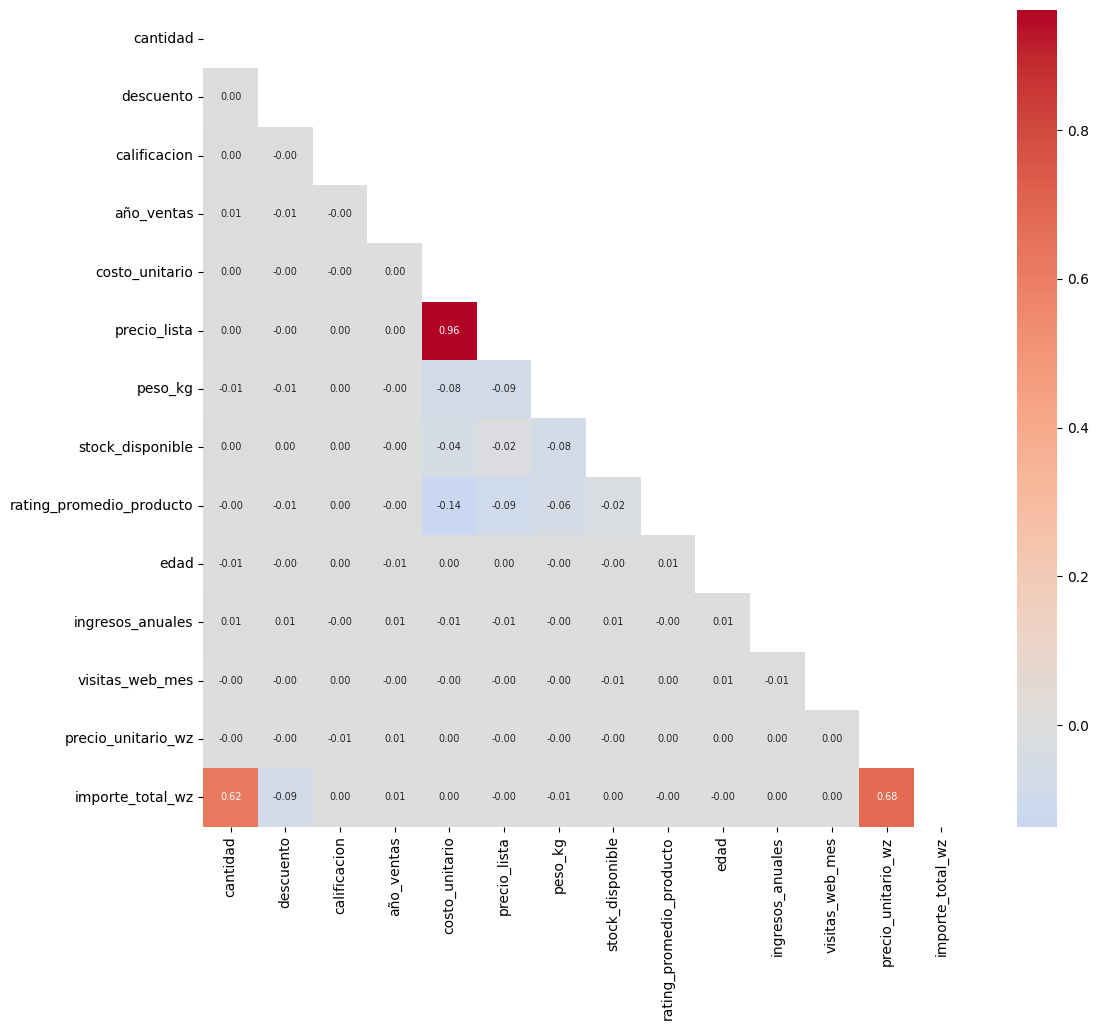

Top 10 pares con mayor correlación (valor absoluto):
precio_lista        costo_unitario              0.961611
precio_unitario_wz  importe_total_wz            0.683578
importe_total_wz    cantidad                    0.618761
costo_unitario      rating_promedio_producto    0.136386
precio_lista        rating_promedio_producto    0.093282
                    peso_kg                     0.087473
importe_total_wz    descuento                   0.086038
costo_unitario      peso_kg                     0.083239
stock_disponible    peso_kg                     0.078744
peso_kg             rating_promedio_producto    0.060227
dtype: float64


,cantidad,descuento,calificacion,año_ventas,costo_unitario,precio_lista,peso_kg,stock_disponible,rating_promedio_producto,edad,ingresos_anuales,visitas_web_mes,precio_unitario_wz,importe_total_wz
cantidad,1.000000,0.000781,0.002524,0.007175,0.002186,0.002015,-0.006401,0.002683,-0.002295,-0.005461,0.008265,-0.001272,-0.001464,0.618761
descuento,0.000781,1.000000,-0.002678,-0.006628,-0.004338,-0.002499,-0.008505,0.000552,-0.007324,-0.000938,0.009475,-0.000737,-0.000098,-0.086038
calificacion,0.002524,-0.002678,1.000000,-0.001121,-0.000729,0.000692,0.004128,0.002129,0.003018,0.004603,-0.003231,0.002079,-0.005543,0.000939
año_ventas,0.007175,-0.006628,-0.001121,1.000000,0.000101,0.000343,-0.004102,-0.002994,-0.004162,-0.008781,0.005536,-0.002913,0.005062,0.007618
costo_unitario,0.002186,-0.004338,-0.000729,0.000101,1.000000,0.961611,-0.083239,-0.044386,-0.136386,0.004430,-0.005925,-0.003166,0.000271,0.000006
precio_lista,0.002015,-0.002499,0.000692,0.000343,0.961611,1.000000,-0.087473,-0.016748,-0.093282,0.004961,-0.006077,-0.003360,-0.001546,-0.001886
peso_kg,-0.006401,-0.008505,0.004128,-0.004102,-0.083239,-0.087473,1.000000,-0.078744,-0.060227,-0.002048,-0.002061,-0.002150,-0.002454,-0.006885
stock_disponible,0.002683,0.000552,0.002129,-0.002994,-0.044386,-0.016748,-0.078744,1.000000,-0.023955,-0.000673,0.006113,-0.010190,-0.002939,0.000004
rating_promedio_producto,-0.002295,-0.007324,0.003018,-0.004162,-0.136386,-0.093282,-0.060227,-0.023955,1.000000,0.007237,-0.001464,0.001963,0.001921,-0.002012
edad,-0.005461,-0.000938,0.004603,-0.008781,0.004430,0.004961,-0.002048,-0.000673,0.007237,1.000000,0.010654,0.010527,0.002398,-0.002472


In [15]:
se.matriz_correlacion(df,cols_excluir=cols_excluir)

**Observación:** usa esto solo como mapa orientativo de por dónde tirar en 
el bivariante — no saques conclusiones de negocio todavía, es un cruce 
puramente numérico.

## Relaciones cruzadas

### PRODUCTO

¿Los precios "outlier" que hemos detectado se concentran en alguna categoría o marca concreta?

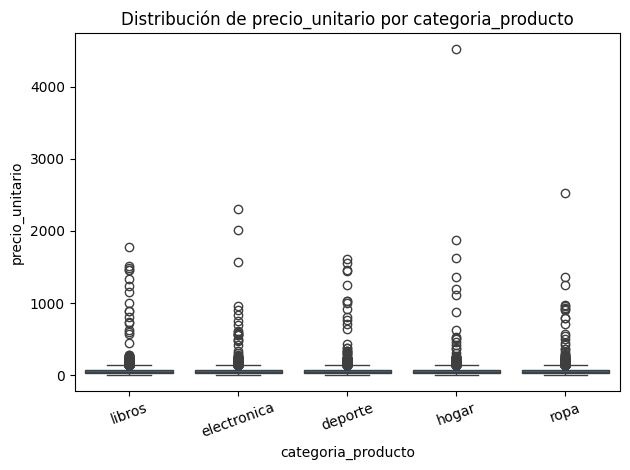

Resumen de precio_unitario por categoria_producto:
                      count   mean    std   min    25%    50%    75%      max
categoria_producto                                                           
deporte             10299.0  56.67  52.75  5.18  29.10  47.48  73.26  1613.47
electronica         10596.0  56.30  52.85  5.28  29.29  47.16  72.98  2306.30
hogar               10304.0  56.39  65.82  5.40  29.32  47.22  72.58  4522.28
libros              10550.0  56.80  56.26  5.30  29.25  47.31  72.20  1772.11
ropa                10251.0  56.05  52.85  5.09  29.11  46.39  72.10  2526.94


,count,mean,std,min,25%,50%,75%,max
categoria_producto,,,,,,,,
deporte,10299.0,56.67,52.75,5.18,29.10,47.48,73.26,1613.47
electronica,10596.0,56.30,52.85,5.28,29.29,47.16,72.98,2306.30
hogar,10304.0,56.39,65.82,5.40,29.32,47.22,72.58,4522.28
libros,10550.0,56.80,56.26,5.30,29.25,47.31,72.20,1772.11
ropa,10251.0,56.05,52.85,5.09,29.11,46.39,72.10,2526.94


In [27]:
se.boxplot_bivar(
    df,
    col_cat="categoria_producto",
    col_num="precio_unitario"
)

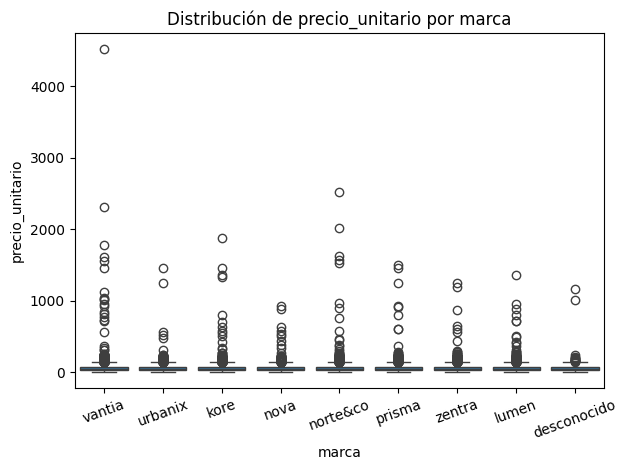

Resumen de precio_unitario por marca:
               count   mean    std   min    25%    50%    75%      max
marca                                                                 
desconocido    567.0  60.19  71.55  5.77  29.62  46.87  75.50  1159.36
kore          6263.0  56.45  54.42  5.54  29.29  47.03  71.94  1874.15
lumen         4707.0  56.98  49.62  5.09  29.27  47.48  72.68  1364.40
norte&co      7497.0  56.44  61.92  5.47  29.17  47.07  72.59  2526.94
nova          5844.0  56.12  40.72  5.30  29.71  48.21  73.75   925.81
prisma        5193.0  56.04  53.00  5.29  29.33  46.91  71.91  1493.65
urbanix       4029.0  55.40  47.82  5.79  28.62  45.93  71.23  1458.39
vantia       10898.0  57.22  71.93  5.18  29.06  47.04  73.41  4522.28
zentra        7002.0  55.74  43.49  5.37  29.21  47.01  71.99  1246.58


,count,mean,std,min,25%,50%,75%,max
marca,,,,,,,,
desconocido,567.0,60.19,71.55,5.77,29.62,46.87,75.50,1159.36
kore,6263.0,56.45,54.42,5.54,29.29,47.03,71.94,1874.15
lumen,4707.0,56.98,49.62,5.09,29.27,47.48,72.68,1364.40
norte&co,7497.0,56.44,61.92,5.47,29.17,47.07,72.59,2526.94
nova,5844.0,56.12,40.72,5.30,29.71,48.21,73.75,925.81
prisma,5193.0,56.04,53.00,5.29,29.33,46.91,71.91,1493.65
urbanix,4029.0,55.40,47.82,5.79,28.62,45.93,71.23,1458.39
vantia,10898.0,57.22,71.93,5.18,29.06,47.04,73.41,4522.28
zentra,7002.0,55.74,43.49,5.37,29.21,47.01,71.99,1246.58


In [28]:
se.boxplot_bivar(
    df,
    col_cat="marca",
    col_num="precio_unitario"
)

**Observación:** si alguna categoría/marca tiene la caja completa desplazada 
hacia arriba (no solo bigotes largos), confirma que es un segmento premium 
real y no ruido.

¿El coste unitario y el precio de lista guardan la relación esperada (margen positivo) en todas las categorías?

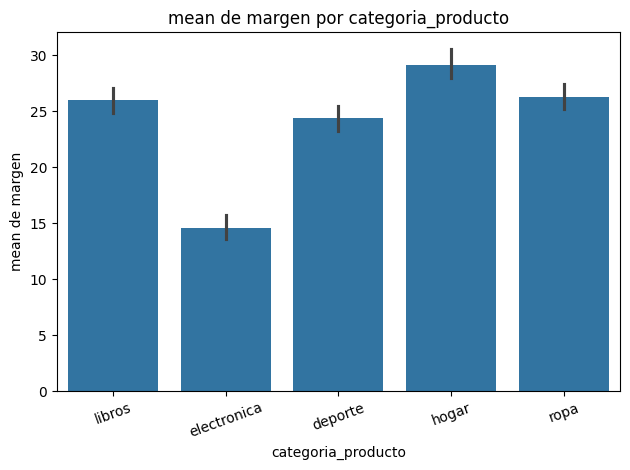

mean de margen por categoria_producto:
categoria_producto
hogar          29.17
ropa           26.27
libros         26.03
deporte        24.36
electronica    14.60
Name: margen, dtype: float64


categoria_producto
hogar          29.17
ropa           26.27
libros         26.03
deporte        24.36
electronica    14.60
Name: margen, dtype: float64

In [30]:
df['margen'] = df['precio_unitario'] - df['costo_unitario']
se.barplot(df, col_cat="categoria_producto", col_num="margen")

¿Qué categorías tienen mayor tasa de devolución?

In [31]:
df.groupby('categoria_producto')['devuelto'].apply(lambda x: (x == 'si').mean() * 100).round(2).sort_values(ascending=False)

categoria_producto
ropa           6.06
electronica    6.04
hogar          5.95
deporte        5.71
libros         5.66
Name: devuelto, dtype: float64

In [32]:
tasa_devolucion_global

np.float64(5.882692307692308)

**Observación:** compara cada valor contra tu `tasa_devolucion_global`. 
Si todas las categorías están muy cerca de esa media, la devolución no 
depende del tipo de producto — hay que buscar la causa en otro sitio.

**Observación:** la tasa de devolución NO varía de forma relevante por 
`categoria_producto` (rango 5.66%-6.06%, todas dentro de ~0.2 puntos de 
la media global 5.88%). El tipo de producto no explica por qué se 
devuelve un pedido. La causa hay que buscarla en otro sitio: canal de 
compra, método de pago, si hubo envío gratis o descuento aplicado.

¿Existe relación entre calificación media del producto y su precio?

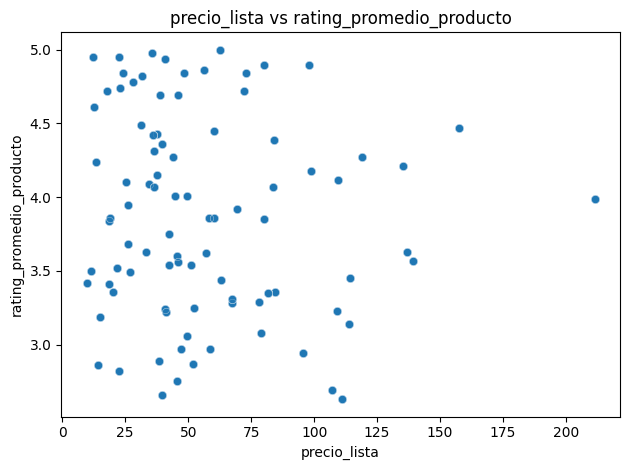

Correlación de Pearson entre precio_lista y rating_promedio_producto: -0.0933


np.float64(-0.09328180591582048)

In [33]:
se.scatterplot(df, col_x="precio_lista", col_y="rating_promedio_producto")

### CANAL Y MÉTODO DE PAGO

¿La tasa de devolución varía según el canal de compra?

In [34]:
df.groupby('canal')['devuelto'].apply(lambda x: (x == 'si').mean() * 100).round(2).sort_values(ascending=False)

canal
app movil        6.08
tienda fisica    5.88
web              5.78
marketplace      5.71
Name: devuelto, dtype: float64

¿Y según el método de pago?

In [35]:
df.groupby('metodo_pago')['devuelto'].apply(lambda x: (x == 'si').mean() * 100).round(2).sort_values(ascending=False)

metodo_pago
tarjeta de credito    6.17
tarjeta de debito     5.90
transferencia         5.87
paypal                5.66
contrareembolso       5.45
desconocido           4.74
Name: devuelto, dtype: float64

¿El envío gratis se asocia con más devoluciones? (hipótesis: menos "coste psicológico" al devolver)

In [36]:
df.groupby('envio_gratis')['devuelto'].apply(lambda x: (x == 'si').mean() * 100).round(2)

envio_gratis
no    5.93
si    5.77
Name: devuelto, dtype: float64

¿El importe medio de compra varía según canal?

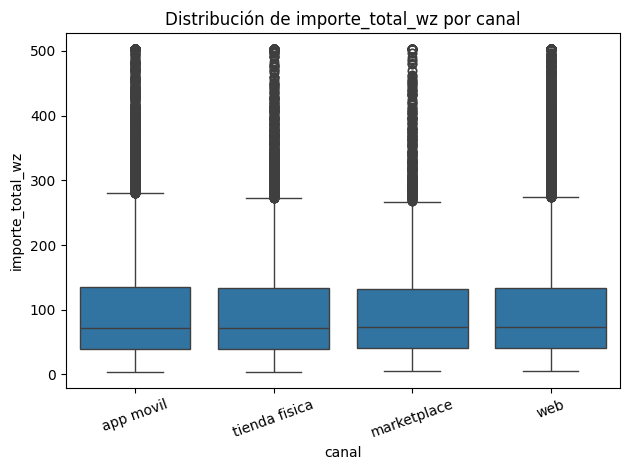

Resumen de importe_total_wz por canal:
                 count    mean    std   min    25%    50%     75%     max
canal                                                                    
app movil      15498.0  104.35  95.87  4.22  39.65  71.79  135.77  503.06
marketplace     5235.0  104.40  95.35  4.71  40.33  73.79  131.30  503.06
tienda fisica  10380.0  102.56  92.90  4.40  40.04  71.96  132.95  503.06
web            20887.0  104.77  95.67  4.63  40.23  73.14  133.86  503.06


,count,mean,std,min,25%,50%,75%,max
canal,,,,,,,,
app movil,15498.0,104.35,95.87,4.22,39.65,71.79,135.77,503.06
marketplace,5235.0,104.40,95.35,4.71,40.33,73.79,131.30,503.06
tienda fisica,10380.0,102.56,92.90,4.40,40.04,71.96,132.95,503.06
web,20887.0,104.77,95.67,4.63,40.23,73.14,133.86,503.06


In [37]:
se.boxplot_bivar(df, col_cat="canal", col_num="importe_total_wz")

¿Canal y método de pago están relacionados? (¿la gente paga distinto según dónde compra?)

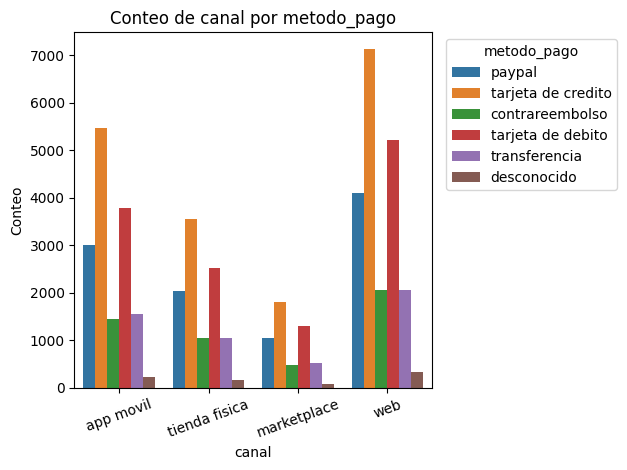

Tabla de conteos: canal vs metodo_pago
metodo_pago    contrareembolso  desconocido  paypal  tarjeta de credito  tarjeta de debito  transferencia
canal                                                                                                    
app movil                 1450          227    3018                5464               3792           1547
marketplace                482           76    1040                1817               1294            526
tienda fisica             1040          154    2049                3552               2528           1057
web                       2059          323    4112                7131               5211           2051


metodo_pago,contrareembolso,desconocido,paypal,tarjeta de credito,tarjeta de debito,transferencia
canal,,,,,,
app movil,1450,227,3018,5464,3792,1547
marketplace,482,76,1040,1817,1294,526
tienda fisica,1040,154,2049,3552,2528,1057
web,2059,323,4112,7131,5211,2051


In [38]:
se.countplot_hue(df, col_cat="canal", hue="metodo_pago")

**Observación:** `canal` tampoco diferencia la tasa de devolución 
(rango 5.71%-6.08%, sin desviación relevante respecto al 5.88% global).

In [39]:
df.groupby('metodo_pago')['devuelto'].apply(lambda x: (x == 'si').mean() * 100).round(2).sort_values(ascending=False)

metodo_pago
tarjeta de credito    6.17
tarjeta de debito     5.90
transferencia         5.87
paypal                5.66
contrareembolso       5.45
desconocido           4.74
Name: devuelto, dtype: float64

In [40]:
df.groupby('envio_gratis')['devuelto'].apply(lambda x: (x == 'si').mean() * 100).round(2)

envio_gratis
no    5.93
si    5.77
Name: devuelto, dtype: float64

Ejecuta esas dos y dime qué sale. Si metodo_pago y envio_gratis también salen planos, tendremos un hallazgo de negocio importante: la devolución parece ser aleatoria/no explicada por estas variables categóricas, y habría que mirar si depende de algo numérico (por ejemplo descuento, calificacion, o el precio_unitario del producto) en vez de categóricas.

#### Dataframe Clientes

In [14]:
clientes.dtypes

id_cliente              str
n_pedidos             int64
gasto_total         float64
edad                float64
ciudad                  str
segmento_cliente        str
ingresos_anuales      int64
ticket_medio        float64
dtype: object

In [18]:
se.detectar_outliers(clientes)

Columna: n_pedidos
Q1: 5.000
Q3: 8.000
IQR: 3.000
Límite inferior: 0.500
Límite superior: 12.500
Outliers encontrados: 109
El porcentaje de Outliers en n_pedidos es: 1.365 %

Describe de los outliers en n_pedidos:
count    109.000
mean      13.853
std        1.268
min       13.000
25%       13.000
50%       13.000
75%       14.000
max       20.000
Name: n_pedidos, dtype: float64
--------------------------------------------------
Columna: gasto_total
Q1: 411.250
Q3: 890.565
IQR: 479.315
Límite inferior: -307.723
Límite superior: 1609.539
Outliers encontrados: 129
El porcentaje de Outliers en gasto_total es: 1.615 %

Describe de los outliers en gasto_total:
count     129.000
mean     1835.344
std       196.415
min      1609.770
25%      1682.810
50%      1785.860
75%      1954.542
max      2746.480
Name: gasto_total, dtype: float64
--------------------------------------------------
Columna: edad
Q1: 32.000
Q3: 48.000
IQR: 16.000
Límite inferior: 8.000
Límite superior: 72.000
Outliers enc